# US-04 — GAT no Colab (20 Execuções Independentes)

**Objetivo:** Treinar exclusivamente o modelo GAT no Google Colab usando dados já processados em `data/processed` no Google Drive e salvar **20 checkpoints independentes**.

**Escopo deste notebook:**
- Montar Google Drive e localizar automaticamente `data/processed`
- Carregar `X_*.npy` e `y_*.npy`
- Construir grafos k-NN para o GAT
- Executar 20 treinos independentes (`gat_run_01.pt` a `gat_run_20.pt`)
- Avaliar o melhor run no conjunto de teste

**Arquivos esperados em `data/processed`:**
- `scaler.pkl`
- `split_config.json`
- `X_train.npy`, `X_val.npy`, `X_test.npy`
- `y_train.npy`, `y_val.npy`, `y_test.npy`

**Saída principal:** pasta `models/gat_runs_20` com exatamente 20 checkpoints do GAT.

## 1. Setup e Seeds

In [1]:
# ── Instalar PyTorch Geometric no Colab ───────────────────────────────────
# Colab não tem PyG por padrão. Esta célula instala apenas quando necessário.
import importlib

if not importlib.util.find_spec("torch_geometric"):
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "torch-geometric"], check=True)
    print("PyTorch Geometric installed.")
else:
    print("PyTorch Geometric already available.")

PyTorch Geometric already available.


In [ ]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# -- Environment detection (local vs Google Colab) --------------------------------
IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")

if IN_COLAB:
    COLAB_REPO = Path("/content/anomaly_detection_models_comparison")
    if not COLAB_REPO.exists():
        os.system(
            "git clone https://github.com/camara0729/anomaly_detection_models_comparison.git "
            "/content/anomaly_detection_models_comparison"
        )
    PROJECT_ROOT = COLAB_REPO
else:
    PROJECT_ROOT = Path.cwd().resolve().parent if (Path.cwd().name == "notebooks") else Path.cwd().resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.gat import (
    VibrationGAT,
    EarlyStopping,
    make_graph_dataloaders,
    epoch_step_gat,
)
from src.preprocessing import compute_statistical_features, build_knn_graph

# -- Seeds -------------------------------------------------------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# -- Device ------------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Project root: {PROJECT_ROOT}")

Device: cuda
  GPU: NVIDIA GeForce RTX 3050 Laptop GPU
  VRAM: 4.3 GB
Project root: /home/camara/workspace/projetos_educacionais/anomaly_detection_comparison


## 2. Montar Drive e Localizar data/processed (Colab)

In [ ]:
# -- Localização automática de data/processed no Google Drive ----------------------
FOLDER_ID = "1iLHFoAN4NK4gOVJHa07nxJMCz10dChJt"
REQUIRED_PROCESSED_FILES = {
    "scaler.pkl",
    "split_config.json",
    "X_train.npy", "X_val.npy", "X_test.npy",
    "y_train.npy", "y_val.npy", "y_test.npy",
}

def is_valid_processed_dir(path: Path) -> bool:
    if not path.exists() or not path.is_dir():
        return False
    file_names = {p.name for p in path.iterdir() if p.is_file()}
    return REQUIRED_PROCESSED_FILES.issubset(file_names)

def find_processed_dir_in_drive() -> Path:
    candidates = [
        Path(f"/content/drive/MyDrive/.shortcut-targets-by-id/{FOLDER_ID}/data/processed"),
        Path("/content/drive/MyDrive/anomaly_detection_models_comparison/data/processed"),
        Path("/content/drive/MyDrive/anomaly_detection_comparison/data/processed"),
        Path("/content/drive/Shareddrives/anomaly_detection_models_comparison/data/processed"),
    ]
    for c in candidates:
        if is_valid_processed_dir(c):
            return c

    roots = [Path("/content/drive/MyDrive"), Path("/content/drive/Shareddrives")]
    for root in roots:
        if not root.exists():
            continue
        for split_file in root.rglob("split_config.json"):
            processed_dir = split_file.parent
            if is_valid_processed_dir(processed_dir):
                return processed_dir

    raise FileNotFoundError(
        "Nao foi possivel localizar data/processed com os arquivos esperados no Drive."
    )

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive", force_remount=False)
    DRIVE_PROCESSED_DIR = find_processed_dir_in_drive()
    DRIVE_PROJECT_DIR = DRIVE_PROCESSED_DIR.parent.parent
    DATA_DIR = DRIVE_PROCESSED_DIR
    print(f"Drive data/processed: {DRIVE_PROCESSED_DIR}")
else:
    DRIVE_PROCESSED_DIR = None
    DRIVE_PROJECT_DIR = None
    DATA_DIR = PROJECT_ROOT / "data" / "processed"
    if not is_valid_processed_dir(DATA_DIR):
        raise FileNotFoundError(
            f"Diretorio invalido: {DATA_DIR}. Verifique se os arquivos de data/processed existem."
        )
    print(f"Local data/processed: {DATA_DIR}")

print("Arquivos encontrados:")
for fname in sorted(REQUIRED_PROCESSED_FILES):
    print(f"  - {fname}")

## 3. Carregar data/processed e Construir Grafos para o GAT

In [ ]:
# -- Carregar arrays processados ----------------------------------------------------
X_train = np.load(DATA_DIR / "X_train.npy")
X_val   = np.load(DATA_DIR / "X_val.npy")
X_test  = np.load(DATA_DIR / "X_test.npy")
y_train = np.load(DATA_DIR / "y_train.npy")
y_val   = np.load(DATA_DIR / "y_val.npy")
y_test  = np.load(DATA_DIR / "y_test.npy")

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}    y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

# -- Grafos para GAT ----------------------------------------------------------------
K_NEIGHBOURS = 8
graphs_train_path = DATA_DIR / "graphs_train.pt"
graphs_val_path   = DATA_DIR / "graphs_val.pt"
graphs_test_path  = DATA_DIR / "graphs_test.pt"

if graphs_train_path.exists() and graphs_val_path.exists() and graphs_test_path.exists():
    print("Encontrados graphs_*.pt em data/processed. Carregando...")
    graphs_train = torch.load(graphs_train_path, weights_only=False)
    graphs_val   = torch.load(graphs_val_path,   weights_only=False)
    graphs_test  = torch.load(graphs_test_path,  weights_only=False)
else:
    print("graphs_*.pt nao encontrados. Construindo grafos k-NN a partir de X_*.npy...")
    feat_train = compute_statistical_features(X_train)
    feat_val   = compute_statistical_features(X_val)
    feat_test  = compute_statistical_features(X_test)

    graphs_train = build_knn_graph(feat_train, k=K_NEIGHBOURS)
    graphs_val   = build_knn_graph(feat_val,   k=K_NEIGHBOURS)
    graphs_test  = build_knn_graph(feat_test,  k=K_NEIGHBOURS)

# Attach labels explicitly para garantir compatibilidade
for i, g in enumerate(graphs_train):
    g.y = torch.tensor(int(y_train[i]), dtype=torch.long)
for i, g in enumerate(graphs_val):
    g.y = torch.tensor(int(y_val[i]), dtype=torch.long)
for i, g in enumerate(graphs_test):
    g.y = torch.tensor(int(y_test[i]), dtype=torch.long)

print(f"Train graphs: {len(graphs_train)} | sample x shape: {graphs_train[0].x.shape}")
print(f"Val graphs:   {len(graphs_val)}")
print(f"Test graphs:  {len(graphs_test)}")

CLASS_NAMES = ["Normal (P1)", "Inner Race (P2)", "Roller Element (P3)", "Outer Race (P4)"]
for split_name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    counts = np.bincount(y, minlength=4)
    print(f"  {split_name}: {dict(zip(range(4), counts))}")

Train graphs: 9720  |  node features: torch.Size([9, 24])
Val graphs:   1944
Test graphs:  2916
Sample graph: Data(x=[9, 24], edge_index=[2, 8], y=0)
  train: {0: 2430, 1: 2430, 2: 2430, 3: 2430}
  val: {0: 486, 1: 486, 2: 486, 3: 486}
  test: {0: 729, 1: 729, 2: 729, 3: 729}


## 4. Hiperparâmetros e Configuração das 20 Execuções

In [ ]:
# -- Architecture ------------------------------------------------------------------
N_FEAT     = graphs_train[0].x.shape[1]
N_CLASSES  = 4
HIDDEN     = 32
HEADS      = 2
NUM_LAYERS = 2
DROPOUT    = 0.0

# -- Training ----------------------------------------------------------------------
BATCH_SIZE     = 64
LR             = 1e-3
MAX_EPOCHS     = 200
PATIENCE       = 5
SCHED_PATIENCE = 3

# -- Multi-run setup ----------------------------------------------------------------
NUM_RUNS = 20
BASE_RUN_SEED = 42

from datetime import datetime

def make_unique_runset_dir(root_dir: Path, prefix: str = "runset") -> Path:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    candidate = root_dir / f"{prefix}_{timestamp}"
    suffix = 1
    while candidate.exists():
        candidate = root_dir / f"{prefix}_{timestamp}_{suffix:02d}"
        suffix += 1
    candidate.mkdir(parents=True, exist_ok=False)
    return candidate

if IN_COLAB and DRIVE_PROJECT_DIR is not None:
    RUNS_ROOT_DIR = DRIVE_PROJECT_DIR / "models" / "gat_runs_20"
else:
    RUNS_ROOT_DIR = PROJECT_ROOT / "models" / "gat_runs_20"
RUNS_ROOT_DIR.mkdir(parents=True, exist_ok=True)

RUNS_MODELS_DIR = make_unique_runset_dir(RUNS_ROOT_DIR)
RUN_RESULTS_PATH = RUNS_MODELS_DIR / "gat_runs_summary.csv"

print(f"Architecture: hidden={HIDDEN}, heads={HEADS}, layers={NUM_LAYERS}, dropout={DROPOUT}")
print(
    f"Training: batch={BATCH_SIZE}, lr={LR}, max_epochs={MAX_EPOCHS}, "
    f"patience={PATIENCE}, sched_patience={SCHED_PATIENCE}"
)
print(f"Runs: {NUM_RUNS} (seed base={BASE_RUN_SEED})")
print(f"Runs root dir: {RUNS_ROOT_DIR}")
print(f"Active runset dir: {RUNS_MODELS_DIR}")

Architecture: hidden=32, heads=2, layers=2, dropout=0.0
Training:     batch=64, lr=0.001, max_epochs=200, patience=5, sched_patience=3


## 5. DataLoaders

In [6]:
train_loader, val_loader = make_graph_dataloaders(
    graphs_train, graphs_val,
    batch_size=BATCH_SIZE,
    seed=RANDOM_SEED,
)

print(f"Train batches: {len(train_loader)}  ({len(train_loader.dataset)} graphs)")
print(f"Val batches:   {len(val_loader)}  ({len(val_loader.dataset)} graphs)")

Train batches: 152  (9720 graphs)
Val batches:   31  (1944 graphs)


## 6. Definir Modelo e Funções de Treino (Multi-run)

In [ ]:
def set_all_seeds(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def build_gat_model(seed: int) -> VibrationGAT:
    set_all_seeds(seed)
    return VibrationGAT(
        n_feat=N_FEAT,
        n_classes=N_CLASSES,
        hidden=HIDDEN,
        heads=HEADS,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
    )

probe_model = build_gat_model(BASE_RUN_SEED).to(DEVICE)
n_params = sum(p.numel() for p in probe_model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")
print(probe_model)

Trainable parameters: 4,004
VibrationGAT(
  (convs): ModuleList(
    (0): GATConv(24, 32, heads=2)
    (1): GATConv(64, 32, heads=1)
  )
  (acts): ModuleList(
    (0-1): 2 x ELU(alpha=1.0)
  )
  (drops): ModuleList(
    (0-1): 2 x Dropout(p=0.0, inplace=False)
  )
  (classifier): Linear(in_features=32, out_features=4, bias=True)
)


## 7. Função de Treino por Execução

In [ ]:
def train_single_run(run_idx: int, run_seed: int):
    train_loader, val_loader = make_graph_dataloaders(
        graphs_train,
        graphs_val,
        batch_size=BATCH_SIZE,
        seed=run_seed,
    )

    model = build_gat_model(run_seed).to(DEVICE)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=SCHED_PATIENCE
    )
    early_stop = EarlyStopping(patience=PATIENCE)

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
    }

    checkpoint_path = RUNS_MODELS_DIR / f"gat_run_{run_idx:02d}.pt"
    best_val_loss = float("inf")
    best_val_acc = 0.0
    best_epoch = 0

    t_start = time.time()
    for epoch in range(1, MAX_EPOCHS + 1):
        tr_loss, tr_acc = epoch_step_gat(
            model, train_loader, loss_fn, optimizer=optimizer, train=True, device=DEVICE
        )
        vl_loss, vl_acc = epoch_step_gat(
            model, val_loader, loss_fn, optimizer=None, train=False, device=DEVICE
        )

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        scheduler.step(vl_loss)
        early_stop.step(vl_loss)

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_val_acc = vl_acc
            best_epoch = epoch
            torch.save(model.state_dict(), checkpoint_path)

        if early_stop.should_stop:
            break

    train_seconds = time.time() - t_start
    return {
        "run": run_idx,
        "seed": run_seed,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_val_acc": best_val_acc,
        "train_seconds": train_seconds,
        "model_path": str(checkpoint_path),
    }, history

Optimizer: Adam lr=0.001
Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)
EarlyStopping: patience=5


## 8. Treinar GAT 20 Vezes e Salvar Checkpoints

In [ ]:
all_run_histories = {}
run_results = []

for run_idx in range(1, NUM_RUNS + 1):
    run_seed = BASE_RUN_SEED + run_idx - 1
    print(f"[Run {run_idx:02d}/{NUM_RUNS}] seed={run_seed}")

    result, run_history = train_single_run(run_idx=run_idx, run_seed=run_seed)
    run_results.append(result)
    all_run_histories[run_idx] = run_history

    print(
        f"  best_epoch={result['best_epoch']}, "
        f"best_val_loss={result['best_val_loss']:.4f}, "
        f"best_val_acc={result['best_val_acc'] * 100:.2f}%, "
        f"time={result['train_seconds']:.1f}s"
    )

results_df = pd.DataFrame(run_results).sort_values("run").reset_index(drop=True)
results_df.to_csv(RUN_RESULTS_PATH, index=False)

best_row = results_df.sort_values("best_val_loss", ascending=True).iloc[0]
BEST_RUN = int(best_row["run"])
BEST_SEED = int(best_row["seed"])
CHECKPOINT_PATH = Path(best_row["model_path"])
history = all_run_histories[BEST_RUN]

print("\nResumo das 20 execucoes:")
print(results_df[["run", "seed", "best_epoch", "best_val_loss", "best_val_acc", "train_seconds"]].to_string(index=False))
print(f"\nMelhor run: {BEST_RUN:02d} (seed={BEST_SEED})")
print(f"Melhor val_loss: {best_row['best_val_loss']:.4f}")
print(f"Checkpoint selecionado para avaliacao: {CHECKPOINT_PATH}")
print(f"Resumo salvo em: {RUN_RESULTS_PATH}")

# Modelo da melhor execucao para as celulas de avaliacao
model = build_gat_model(BEST_SEED).to(DEVICE)
model.load_state_dict(torch.load(CHECKPOINT_PATH, weights_only=True))
loss_fn = nn.CrossEntropyLoss()

Epoch   1/200 | tr_loss=3.1757 tr_acc=0.7262 | vl_loss=0.9102 vl_acc=0.6970 | lr=1.00e-03 | 3s
Epoch  10/200 | tr_loss=0.1454 tr_acc=0.9433 | vl_loss=0.3054 vl_acc=0.8786 | lr=1.00e-03 | 16s

Early stopping at epoch 14. Best val_loss=0.2828

Total training time: 22.1s
Best val_loss: 0.2828
Model saved to: /home/camara/workspace/projetos_educacionais/anomaly_detection_comparison/models/gat_best.pt


In [ ]:
run_model_files = sorted(RUNS_MODELS_DIR.glob("gat_run_*.pt"))
print(f"Total de checkpoints encontrados: {len(run_model_files)}")
assert len(run_model_files) == NUM_RUNS, (
    f"Esperados {NUM_RUNS} modelos, encontrados {len(run_model_files)}"
)

print("\nModelos salvos:")
for model_file in run_model_files:
    print(f"  - {model_file.name}")

print(f"\nPasta final dos 20 modelos: {RUNS_MODELS_DIR}")

## 9. Curvas de Treinamento (Melhor Run)

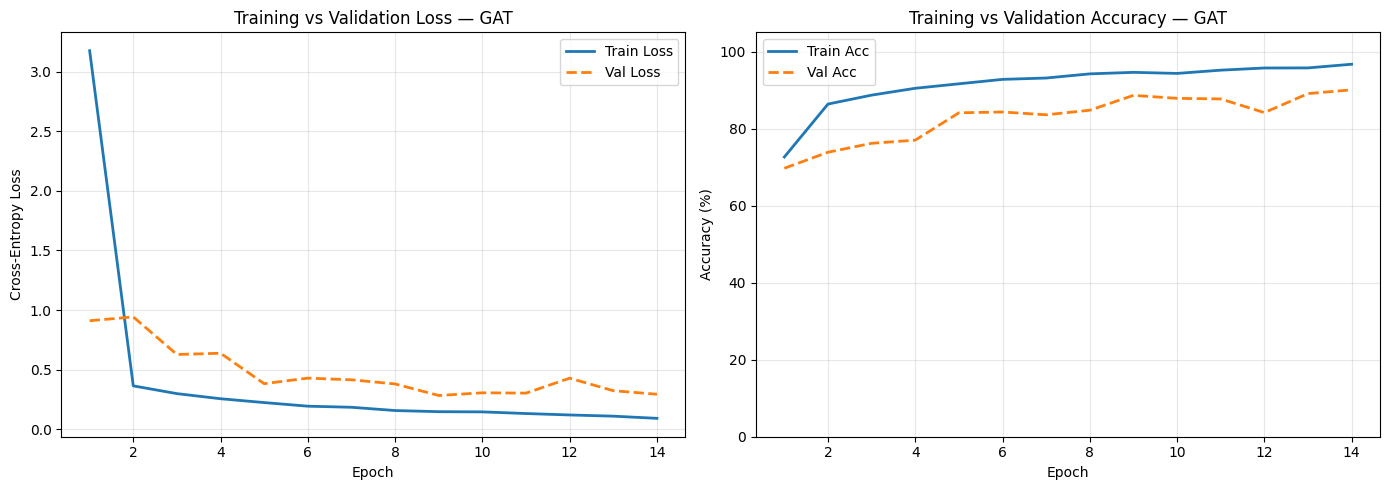

Saved: docs/figures/04_gat_training_curves.png


In [ ]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs, history["train_loss"], label="Train Loss", linewidth=2)
ax1.plot(epochs, history["val_loss"],   label="Val Loss",   linewidth=2, linestyle="--")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.set_title(f"Training vs Validation Loss — GAT (Run {BEST_RUN:02d})")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Accuracy
ax2.plot(epochs, [a * 100 for a in history["train_acc"]], label="Train Acc", linewidth=2)
ax2.plot(epochs, [a * 100 for a in history["val_acc"]],   label="Val Acc",   linewidth=2, linestyle="--")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title(f"Training vs Validation Accuracy — GAT (Run {BEST_RUN:02d})")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 105)
ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()

FIGURES_DIR = PROJECT_ROOT / "docs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
curves_path = FIGURES_DIR / f"04_gat_training_curves_run_{BEST_RUN:02d}.png"
fig.savefig(curves_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {curves_path}")

## 10. Avaliação no Conjunto de Teste (Melhor Run)

In [ ]:
from torch_geometric.loader import DataLoader as PyGDataLoader

print(f"Avaliando melhor run: {BEST_RUN:02d} (checkpoint: {CHECKPOINT_PATH.name})")

model.load_state_dict(torch.load(CHECKPOINT_PATH, weights_only=True))
model.eval()

test_loader = PyGDataLoader(graphs_test, batch_size=BATCH_SIZE, shuffle=False)

test_loss, test_acc = epoch_step_gat(
    model, test_loader, loss_fn, optimizer=None, train=False, device=DEVICE
)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

Test Loss:     0.1684
Test Accuracy: 94.41%


## 11. Matriz de Confusão (Teste, Melhor Run)

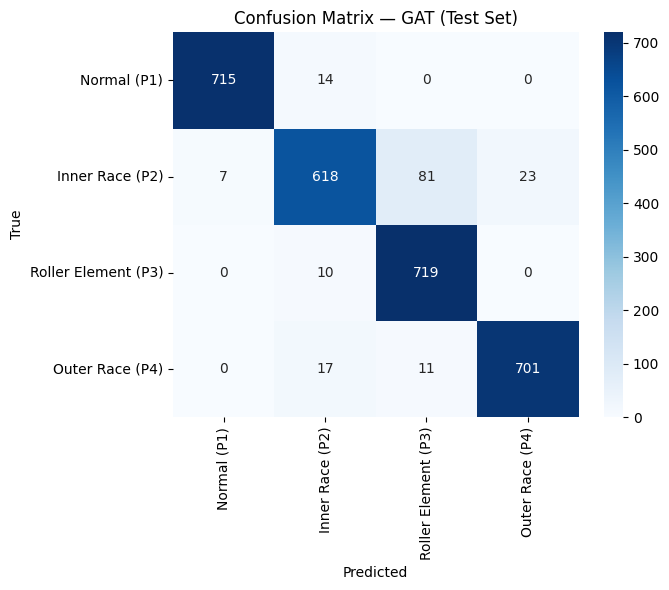


Classification Report:
                     precision    recall  f1-score   support

        Normal (P1)       0.99      0.98      0.99       729
    Inner Race (P2)       0.94      0.85      0.89       729
Roller Element (P3)       0.89      0.99      0.93       729
    Outer Race (P4)       0.97      0.96      0.96       729

           accuracy                           0.94      2916
          macro avg       0.95      0.94      0.94      2916
       weighted avg       0.95      0.94      0.94      2916



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(DEVICE)
        logits = model(batch.x, batch.edge_index, batch.batch)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=ax
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix — GAT (Test Set, Run {BEST_RUN:02d})")
plt.tight_layout()
cm_path = FIGURES_DIR / f"04_gat_confusion_matrix_run_{BEST_RUN:02d}.png"
fig.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"\nClassification Report (Run {BEST_RUN:02d}):")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))
print(f"Saved: {cm_path}")

## 12. Resumo de Entregáveis

Este notebook foi configurado para rodar no Colab com foco exclusivo em GAT e gerar 20 modelos independentes sem sobrescrever execuções anteriores.

**Saídas geradas na execução atual:**
- `models/gat_runs_20/runset_YYYYMMDD_HHMMSS/gat_run_01.pt` ... `gat_run_20.pt`
- `models/gat_runs_20/runset_YYYYMMDD_HHMMSS/gat_runs_summary.csv`
- `docs/figures/04_gat_training_curves_run_XX.png` (melhor run)
- `docs/figures/04_gat_confusion_matrix_run_XX.png` (melhor run)

**Validação no notebook:**
- Montagem de Drive e descoberta automática de `data/processed`
- Treino com dados de `X_*.npy` e `y_*.npy` em `data/processed`
- Assertiva de exatamente 20 checkpoints (`gat_run_*.pt`) por runset